# Modeling, Evaluation & Data Mining
Building models and discovering patterns.

Logistic Regression Accuracy: 0.8776
Decision Tree Accuracy: 0.9489
Random Forest Accuracy: 0.9467


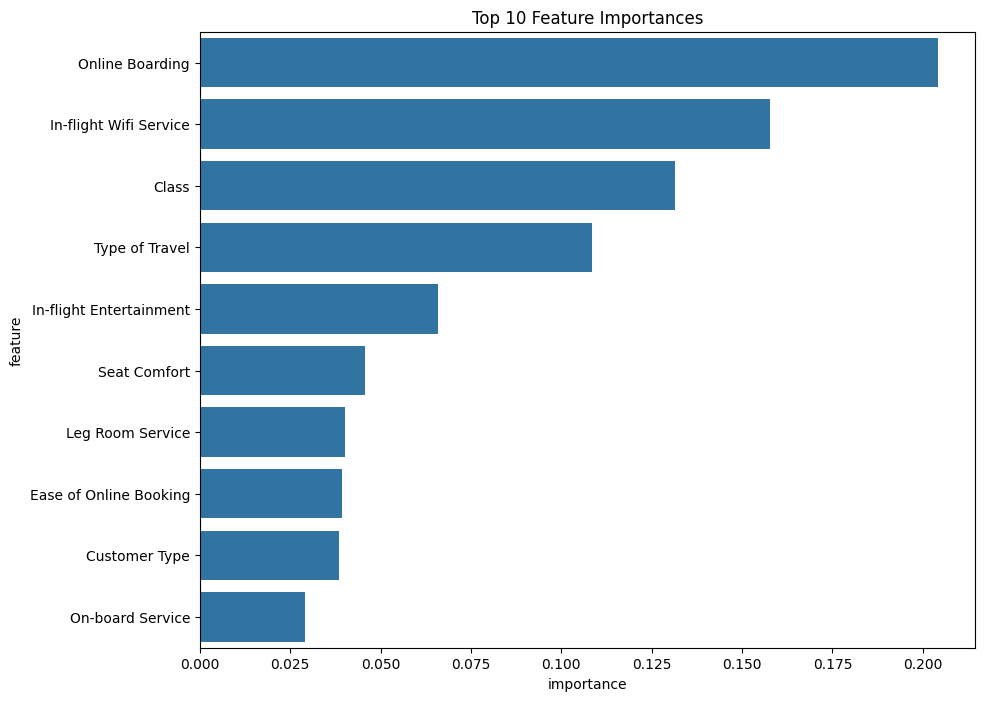

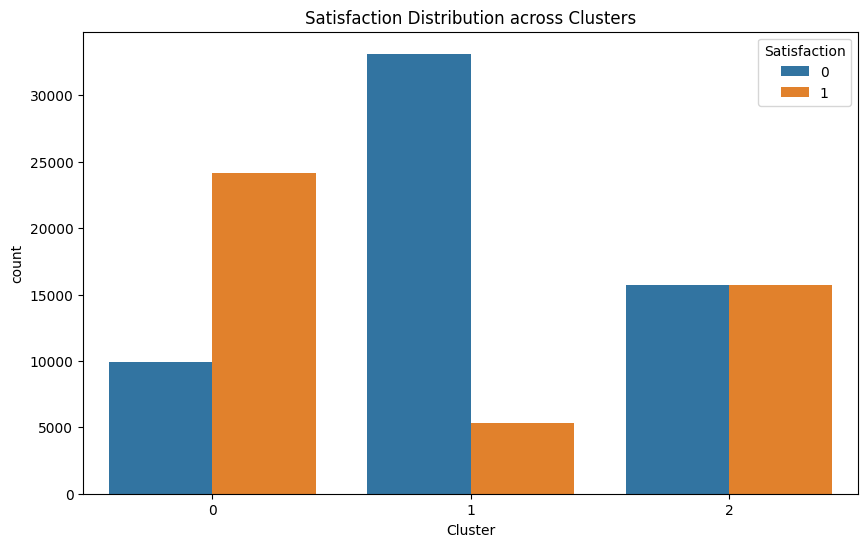

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans

# 1. Load Data (assuming pre-run step 02)
# For demonstration, we'll use the processed files we saved earlier
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

# 2. Train Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train.values.ravel())
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# 3. Feature Importance (Random Forest)
rf = models['Random Forest']
importances = rf.feature_importances_
feat_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feat_df.head(10))
plt.title('Top 10 Feature Importances')
plt.show()

# 4. Data Mining: K-Means Clustering for Segmentation
# Cluster based on service ratings
service_cols = [c for c in X_train.columns if c not in ['Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay']]
X_service = X_train[service_cols]

kmeans = KMeans(n_clusters=3, random_state=42)
X_train['Cluster'] = kmeans.fit_predict(X_service)

# Visualize clusters vs Satisfaction
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', hue=y_train['Satisfaction'], data=X_train)
plt.title('Satisfaction Distribution across Clusters')
plt.show()